In [1]:
from data_utils import *
from import_pkgs import *

In [2]:
rural_atm_2mavg=xr.concat([rural_atm_202402,rural_atm_202403],dim='time').mean(dim='time')
ctrl_atm_2mavg=xr.concat([ctrl_atm_202402,ctrl_atm_202403],dim='time').mean(dim='time')
test_atm_2mavg=xr.concat([test_atm_202402,test_atm_202403],dim='time').mean(dim='time')

In [3]:
rural_lnd_2mavg=xr.concat([rural_lnd_202402,rural_lnd_202403],dim='time').mean(dim='time')
ctrl_lnd_2mavg=xr.concat([ctrl_lnd_202402,ctrl_lnd_202403],dim='time').mean(dim='time')
test_lnd_2mavg=xr.concat([test_lnd_202402,test_lnd_202403],dim='time').mean(dim='time')

In [4]:
rural_atm_2mavg['NOx']=(rural_atm_2mavg['NO']+rural_atm_2mavg['NO2'])
ctrl_atm_2mavg['NOx']=(ctrl_atm_2mavg['NO']+ctrl_atm_2mavg['NO2'])
test_atm_2mavg['NOx']=(test_atm_2mavg['NO']+test_atm_2mavg['NO2'])

In [5]:
def thermo_from_T_Q(T, Q, P, Ps=1.0e5):
    eps = 0.622 
    e = Q * P / (eps + (1.0 - eps) * Q)

    Tc = T - 273.15
    es = 611.2 * np.exp(17.67 * Tc / (Tc + 243.5))

    RH = 100.0 * e / es
    RH = RH.clip(1.0e-6, 100.0)

    alpha = xr.where(T >= 273.15, 238.88, 247.15)
    beta = xr.where(T >= 273.15, 17.368, 17.966)

    gamma = np.log(RH / 100.0) + beta * (T - 273.15) / (alpha + T - 273.15)
    Td = alpha * (gamma / (beta - gamma)) + 273.15

    Tp = T * (Ps / P) ** 0.286
    return Tp / Td

In [6]:
urban_R=thermo_from_T_Q(test_atm_2mavg["T"],test_atm_2mavg["Q"],test_atm_2mavg["PMID"])
rural_R=thermo_from_T_Q(rural_atm_2mavg["T"],rural_atm_2mavg["Q"],rural_atm_2mavg["PMID"])

In [7]:
test_surf = xr.open_dataset(TEST_SURF)
test_PCT_URBAN = test_surf["PCT_URBAN"].sum(dim="numurbl") 

test_lnd_feb_monthly = xr.open_dataset(
    f"{base_dir}/{test_case}/lnd/hist/{test_case}.clm2.h0.2024-02.nc"
)

lat = test_lnd_feb_monthly["lat"]    
lon = test_lnd_feb_monthly["lon"]     
area = test_lnd_feb_monthly["area"]  

/glade/derecho/scratch/yifanc17/tmp/ipykernel_85915/1818283192.py:4: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  test_lnd_feb_monthly = xr.open_dataset(


In [8]:
lnd_highres_mask = area < 300.0 
lnd_gt10_urban_mask=(test_PCT_URBAN>10.0).rename({'gridcell':'lndgrid'})

lnd_combined_mask = lnd_highres_mask & lnd_gt10_urban_mask

grid_idx = np.where(lnd_combined_mask.values)[0]

atm_grid_idx = grid_idx
final_grid_idx = grid_idx
PCT_URBAN_sel = test_PCT_URBAN.isel(gridcell=final_grid_idx)

In [9]:
# atm mask
grid_idx = np.where(lnd_combined_mask.values)[0]
mask = xr.DataArray(
    rural_atm_2mavg["ncol"].isin(grid_idx),
    dims=("ncol",),
    coords={"ncol": rural_atm_2mavg["ncol"]},
)

In [16]:
DEFAULT_PANELS = [
    {
        "title": "Thailand",
        "lat_range": (5, 21),
        "lon_range": (97, 106),
        "x_ticks": np.arange(95, 107, 5),
        "y_ticks": np.arange(5, 22, 5),
    },
    {
        "title": "Philippines",
        "lat_range": (4, 22),
        "lon_range": (116, 127),
        "x_ticks": np.arange(115, 128, 5),
        "y_ticks": np.arange(5, 23, 5),
    },
    {
        "title": "South Korea",
        "lat_range": (33, 39),
        "lon_range": (125, 130),
        "x_ticks": np.arange(125, 131, 2),
        "y_ticks": np.arange(33, 40, 2),
    },
    {
        "title": "Taiwan",
        "lat_range": (21.5, 26),
        "lon_range": (119.5, 122.5),
        "x_ticks": np.arange(120, 123, 2),
        "y_ticks": np.arange(22, 27, 2),
    },
]

def plot_regional_difference_panels(
    data_array,
    scrip_file,
    cmin,
    cmax,
    colorbar_label,
    cmap="coolwarm",
    panels=None,
    figsize=(18, 6),
    width_ratios=(0.56, 0.61, 0.83, 0.67),
    wspace=0.4,
    font_family="DejaVu Sans",
    title_fontsize=20,
    grid_labelsize=12,
    colorbar_ticks=None,
    colorbar_formatter=None,
    colorbar_ticksize=14,
    colorbar_labelsize=20,
    coastline_linewidth=0.6,
):
    if panels is None:
        panels = DEFAULT_PANELS

    fig, axs = plt.subplots(
        1,
        len(panels),
        figsize=figsize,
        subplot_kw={"projection": ccrs.PlateCarree()},
        gridspec_kw={
            "width_ratios": width_ratios,
            "wspace": wspace,
        },
    )

    if len(panels) == 1:
        axs = [axs]

    for ax, panel in zip(axs, panels):
        Plot_2D(
            data_array,
            scrip_file=scrip_file,
            cmap=cmap,
            cmin=cmin,
            cmax=cmax,
            lat_range=panel["lat_range"],
            lon_range=panel["lon_range"],
            title="",
            ax=ax,
            colorbar=False,
            grid_line=False,
            font_family=font_family,
        )

        ax.set_title(panel["title"], fontsize=title_fontsize, fontfamily=font_family)
        ax.coastlines(linewidth=coastline_linewidth)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(
            bottom=False,
            top=False,
            left=False,
            right=False,
            labelbottom=False,
            labeltop=False,
            labelleft=False,
            labelright=False,
        )

        gl = ax.gridlines(
            crs=ccrs.PlateCarree(),
            draw_labels=True,
            xlocs=FixedLocator(panel["x_ticks"]),
            ylocs=FixedLocator(panel["y_ticks"]),
            linewidth=0.4,
            color="gray",
            alpha=0.5,
            linestyle="--",
            auto_inline=False,
        )
        gl.xformatter = cticker.LongitudeFormatter()
        gl.yformatter = cticker.LatitudeFormatter()
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": grid_labelsize}
        gl.ylabel_style = {"size": grid_labelsize}

    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(vmin=cmin, vmax=cmax),
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axs,
        orientation="vertical",
        fraction=0.015,
        pad=0.01,
        shrink=0.8,
    )

    if colorbar_ticks is not None:
        cbar.set_ticks(colorbar_ticks)

    if colorbar_formatter is not None:
        cbar.ax.yaxis.set_major_formatter(colorbar_formatter)

    cbar.ax.tick_params(labelsize=colorbar_ticksize)
    cbar.set_label(colorbar_label, fontsize=colorbar_labelsize)

    return fig, axs, cbar

In [14]:
from matplotlib.ticker import FixedLocator
import cartopy.mpl.ticker as cticker

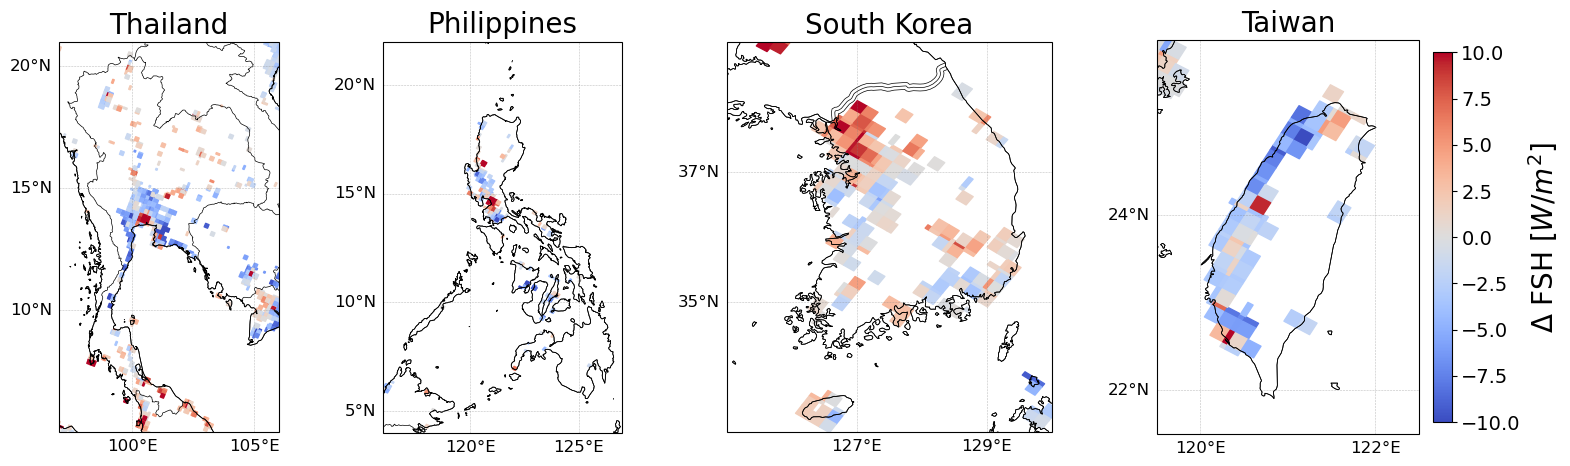

In [15]:
ds1 = rural_lnd_2mavg.FSH.where(lnd_highres_mask & lnd_gt10_urban_mask)
ds2 = test_lnd_2mavg.FSH.where(lnd_highres_mask & lnd_gt10_urban_mask)
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-10,
    cmax=10,
    colorbar_label=r"$\Delta$ FSH [$W/m^2$]",
)

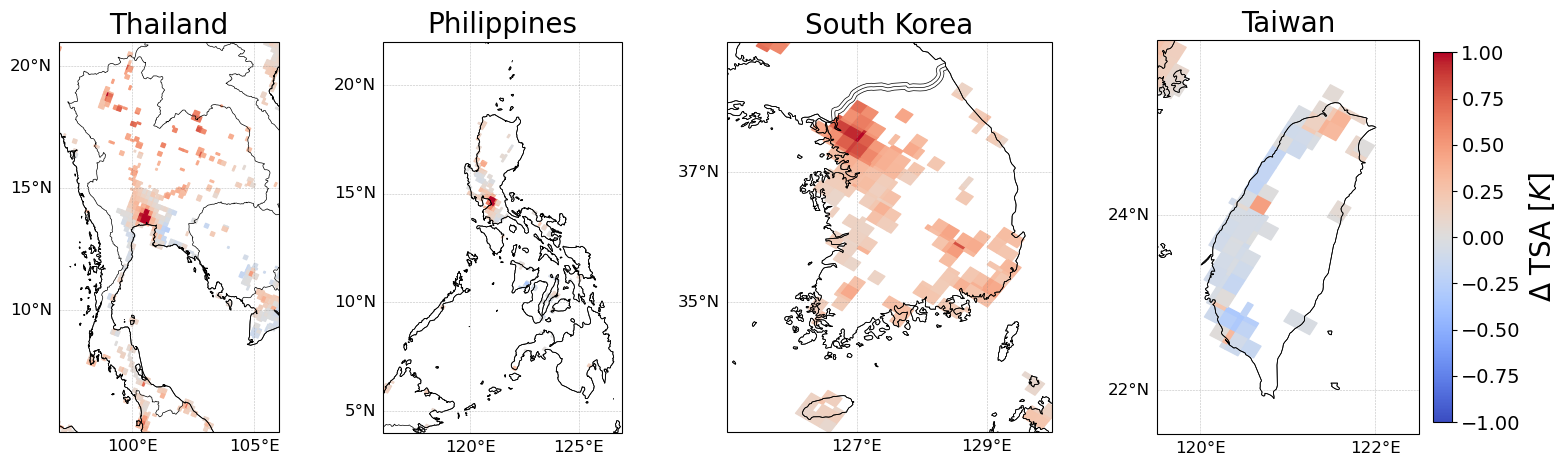

In [18]:
ds1=rural_lnd_2mavg.TSA.where(lnd_highres_mask&lnd_gt10_urban_mask)
ds2=test_lnd_2mavg.TSA.where(lnd_highres_mask&lnd_gt10_urban_mask)
ds3=ds2-ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-1,
    cmax=1,
    colorbar_label=r"$\Delta$ TSA [$K$]",
)

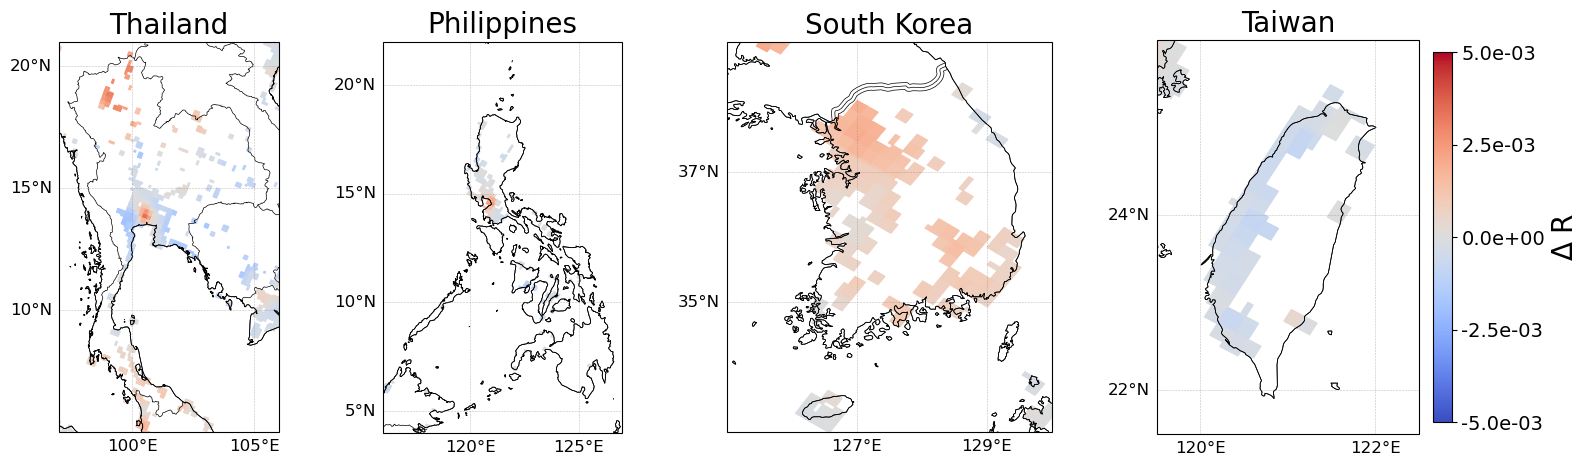

In [17]:
ds1 = rural_R.isel(lev=-1)
ds1=ds1.where(mask,other=float("nan"))
ds2 = urban_R.isel(lev=-1)
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

def sci_fmt(x, pos):
    return f'{x:.1e}'  
    
fig, axs, cbar = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-5e-3,
    cmax=5e-3,
    colorbar_label=r"$\Delta$ R",
    colorbar_ticks=[-5e-3, -2.5e-3, 0, 2.5e-3, 5e-3],
    colorbar_formatter=FuncFormatter(sci_fmt),
)

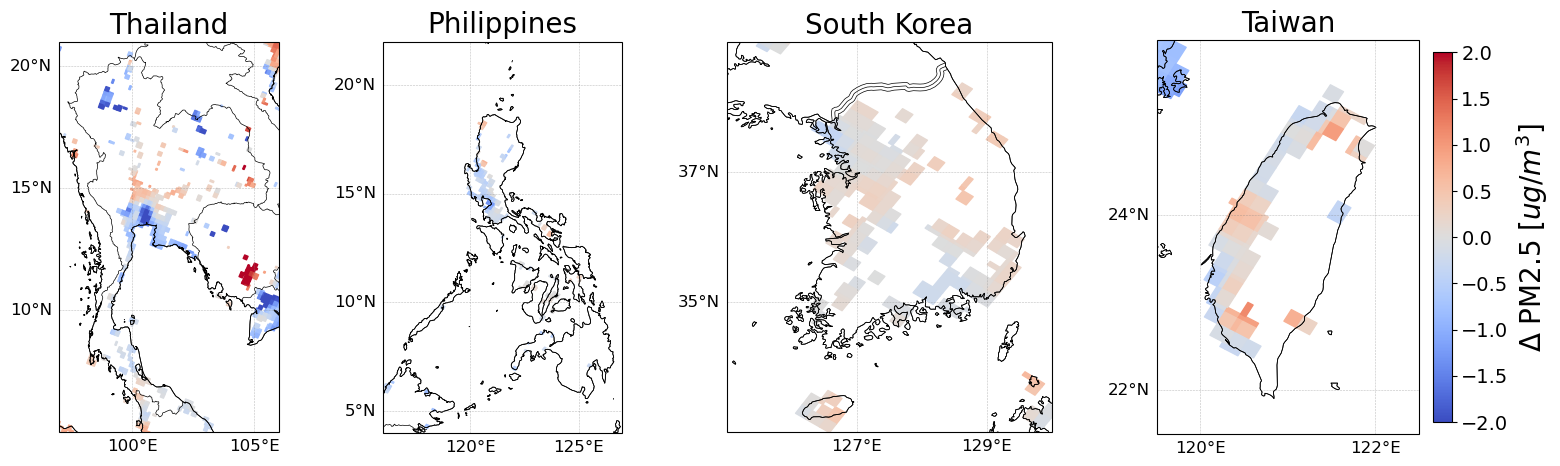

In [19]:
ds1=rural_atm_2mavg.PM25.isel(lev=-1)*1e9
ds1=ds1.where(mask,other=float("nan"))
ds2=test_atm_2mavg.PM25.isel(lev=-1)*1e9
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-2,
    cmax=2,
    colorbar_label=r"$\Delta$ PM2.5 [$ug/m^3$]",
)

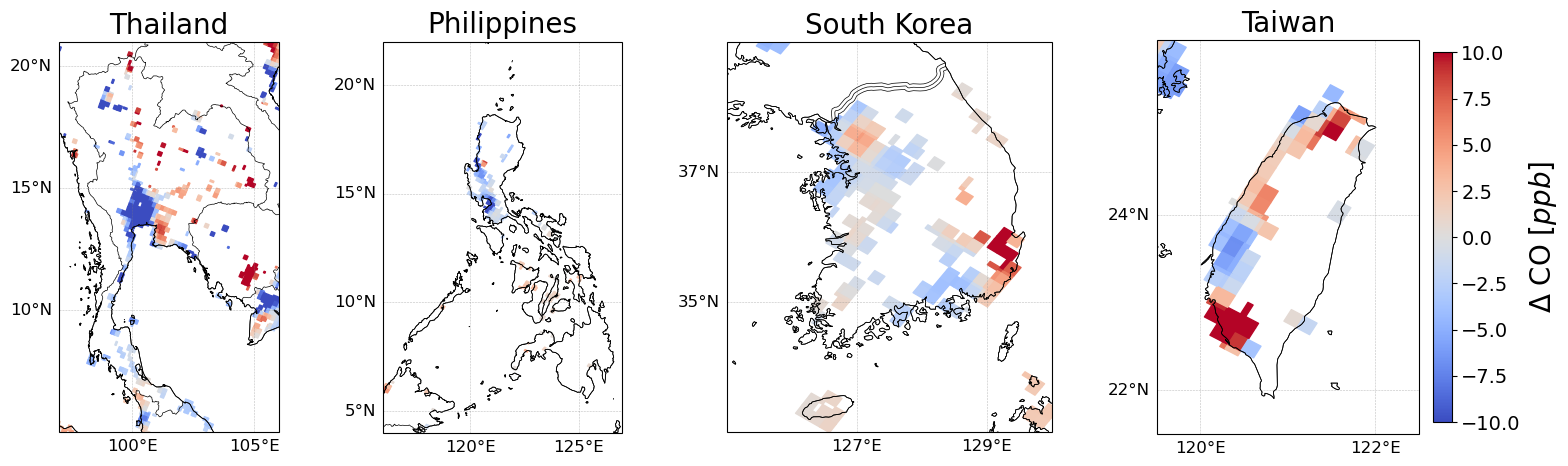

In [24]:
ds1=rural_atm_2mavg.CO.isel(lev=-1)*1e9
ds1=ds1.where(mask,other=float("nan"))
ds2=test_atm_2mavg.CO.isel(lev=-1)*1e9
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-10,
    cmax=10,
    colorbar_label=r"$\Delta$ CO [$ppb$]",
)

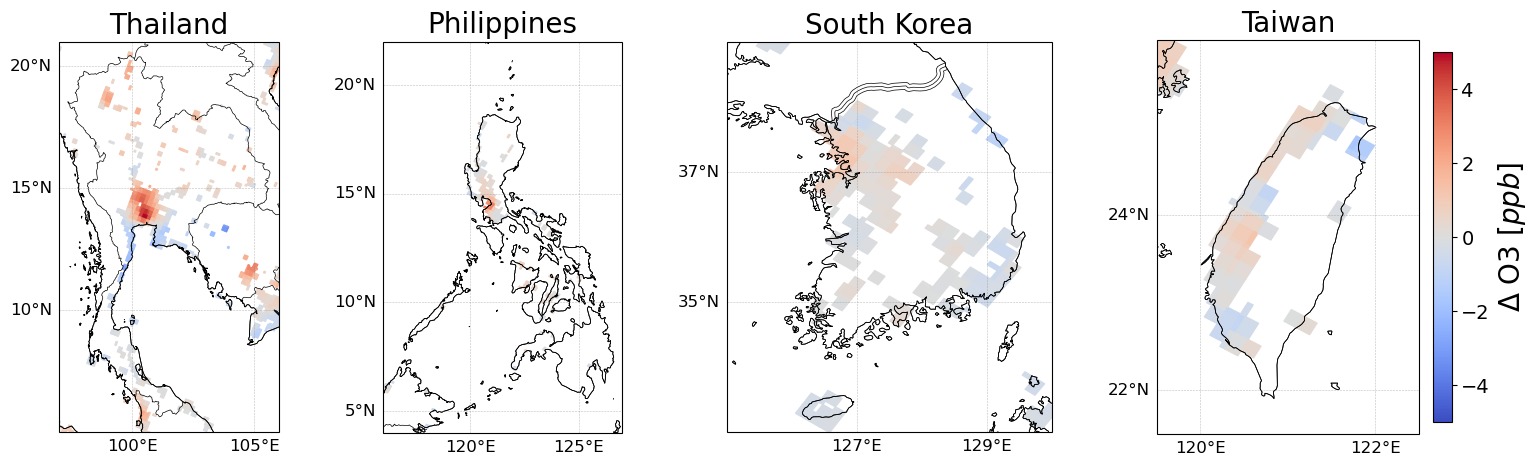

In [20]:
ds1=rural_atm_2mavg.O3.isel(lev=-1)*1e9
ds1=ds1.where(mask,other=float("nan"))
ds2=test_atm_2mavg.O3.isel(lev=-1)*1e9
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-5,
    cmax=5,
    colorbar_label=r"$\Delta$ O3 [$ppb$]",
)

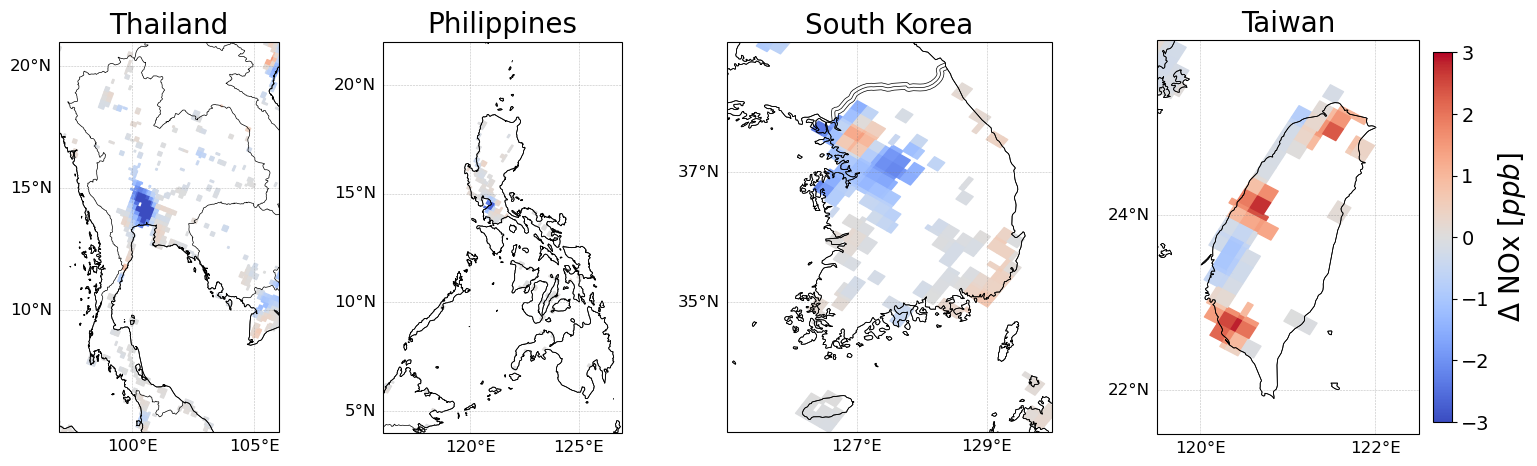

In [21]:
ds1=rural_atm_2mavg.NOx.isel(lev=-1)*1e9
ds1=ds1.where(mask,other=float("nan"))
ds2=test_atm_2mavg.NOx.isel(lev=-1)*1e9
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-3,
    cmax=3,
    colorbar_label=r"$\Delta$ NOx [$ppb$]",
)

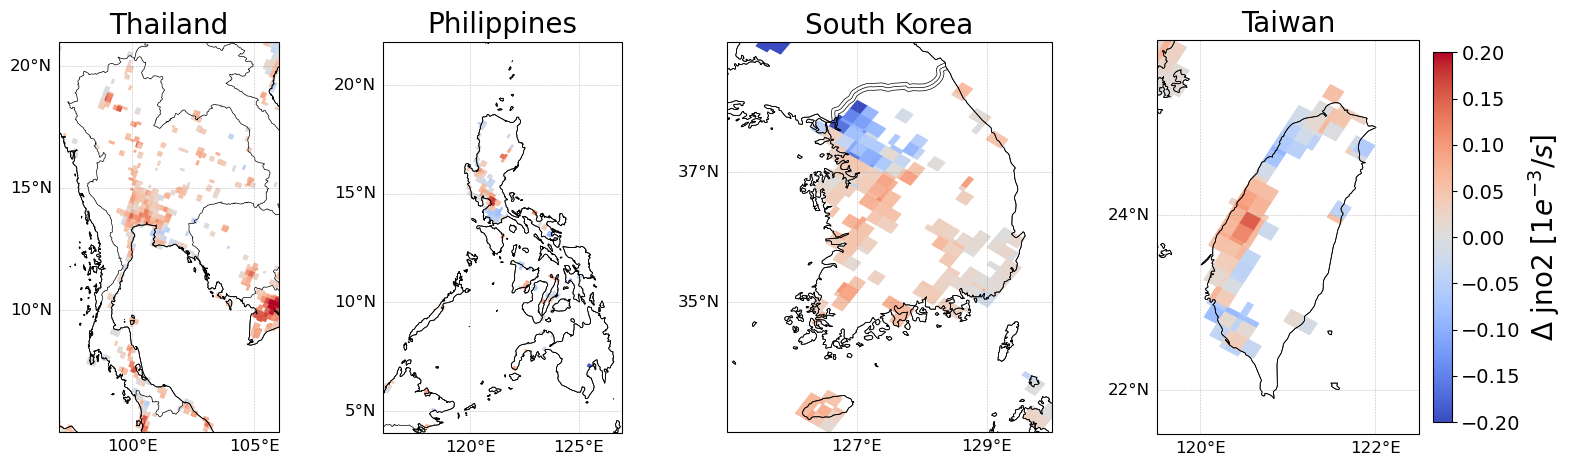

In [22]:
ds1=rural_atm_2mavg.jno2.isel(lev=-1)*1e3
ds1=ds1.where(mask,other=float("nan"))
ds2=test_atm_2mavg.jno2.isel(lev=-1)*1e3
ds2=ds2.where(mask,other=float("nan"))
ds3 = ds2 - ds1

fig, axs, _ = plot_regional_difference_panels(
    data_array=ds3,
    scrip_file=MUSICA_scrip_path,
    cmin=-0.2,
    cmax=0.2,
    colorbar_label=r"$\Delta$ jno2 [$1e^{-3}/s$]",
)